In [1]:
from google.colab import files
uploaded = files.upload()

Saving train_FD001.txt to train_FD001.txt


In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q
print("All libraries ready!")

All libraries ready!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, accuracy_score, f1_score, roc_curve, auc)
import joblib
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports successful!")

✅ All imports successful!


In [4]:
# Column names for NASA CMAPSS (no headers in raw file)
COLUMN_NAMES = [
    'engine_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5',
    'sensor_6','sensor_7','sensor_8','sensor_9','sensor_10',
    'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
    'sensor_16','sensor_17','sensor_18','sensor_19','sensor_20','sensor_21'
]

df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=COLUMN_NAMES)

print(f"✅ Dataset loaded!")
print(f"   Rows    : {len(df)}")
print(f"   Columns : {len(df.columns)}")
print(f"   Engines : {df['engine_id'].nunique()}")
df.head()

✅ Dataset loaded!
   Rows    : 20631
   Columns : 26
   Engines : 100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
# Calculate Remaining Useful Life (RUL) for each engine
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']
df = df.merge(max_cycles, on='engine_id', how='left')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

# Create failure label: 1 = failure within 30 cycles, 0 = normal
THRESHOLD = 30
df['failure_label'] = (df['RUL'] <= THRESHOLD).astype(int)

print(f"✅ RUL computed. Range: {df['RUL'].min()} to {df['RUL'].max()}")
print(f"   Failure samples : {df['failure_label'].sum()}")
print(f"   Normal samples  : {(df['failure_label']==0).sum()}")
df[['engine_id','cycle','RUL','failure_label']].head(10)

✅ RUL computed. Range: 0 to 361
   Failure samples : 3100
   Normal samples  : 17531


,engine_id,cycle,RUL,failure_label
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0
5,1,6,186,0
6,1,7,185,0
7,1,8,184,0
8,1,9,183,0
9,1,10,182,0


In [6]:
# Remove sensors with near-zero variance (useless for prediction)
CONSTANT_SENSORS = ['sensor_1','sensor_5','sensor_6',
                    'sensor_10','sensor_16','sensor_18','sensor_19']
df.drop(columns=CONSTANT_SENSORS, inplace=True)

# Useful sensor columns
FEATURE_SENSORS = ['sensor_2','sensor_3','sensor_4','sensor_7','sensor_8',
                   'sensor_9','sensor_11','sensor_12','sensor_13','sensor_14',
                   'sensor_15','sensor_17','sensor_20','sensor_21']

# Add rolling mean and std per engine (window = 10 cycles)
df = df.sort_values(['engine_id', 'cycle'])
for sensor in FEATURE_SENSORS:
    df[f'{sensor}_roll_mean'] = (df.groupby('engine_id')[sensor]
                                   .transform(lambda x: x.rolling(10, min_periods=1).mean()))
    df[f'{sensor}_roll_std']  = (df.groupby('engine_id')[sensor]
                                   .transform(lambda x: x.rolling(10, min_periods=1).std().fillna(0)))

df.dropna(inplace=True)
print(f"✅ Feature engineering done! Dataset shape: {df.shape}")

✅ Feature engineering done! Dataset shape: (20631, 49)


In [7]:
# Define features and target
exclude_cols = ['engine_id', 'cycle', 'RUL', 'failure_label']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['failure_label']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features to 0-1 range
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Split complete!")
print(f"   Training samples : {X_train_sc.shape[0]}")
print(f"   Testing samples  : {X_test_sc.shape[0]}")
print(f"   Features used    : {X_train_sc.shape[1]}")

✅ Split complete!
   Training samples : 16504
   Testing samples  : 4127
   Features used    : 45


In [8]:
print("⏳ Training Random Forest... (may take 30-60 seconds)")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_sc, y_train)

print("✅ Model trained successfully!")

# Cross-validation score
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc')
print(f"   Cross-Val ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

⏳ Training Random Forest... (may take 30-60 seconds)
✅ Model trained successfully!
   Cross-Val ROC-AUC: 0.9924 ± 0.0008


In [9]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)

print("="*45)
print("        MODEL EVALUATION REPORT")
print("="*45)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc:.4f}")
print("="*45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal (0)', 'Failure (1)']))

        MODEL EVALUATION REPORT
  Accuracy  : 96.51%
  F1 Score  : 0.8899
  ROC-AUC   : 0.9944

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.97      0.98      3507
 Failure (1)       0.85      0.94      0.89       620

    accuracy                           0.97      4127
   macro avg       0.92      0.95      0.93      4127
weighted avg       0.97      0.97      0.97      4127



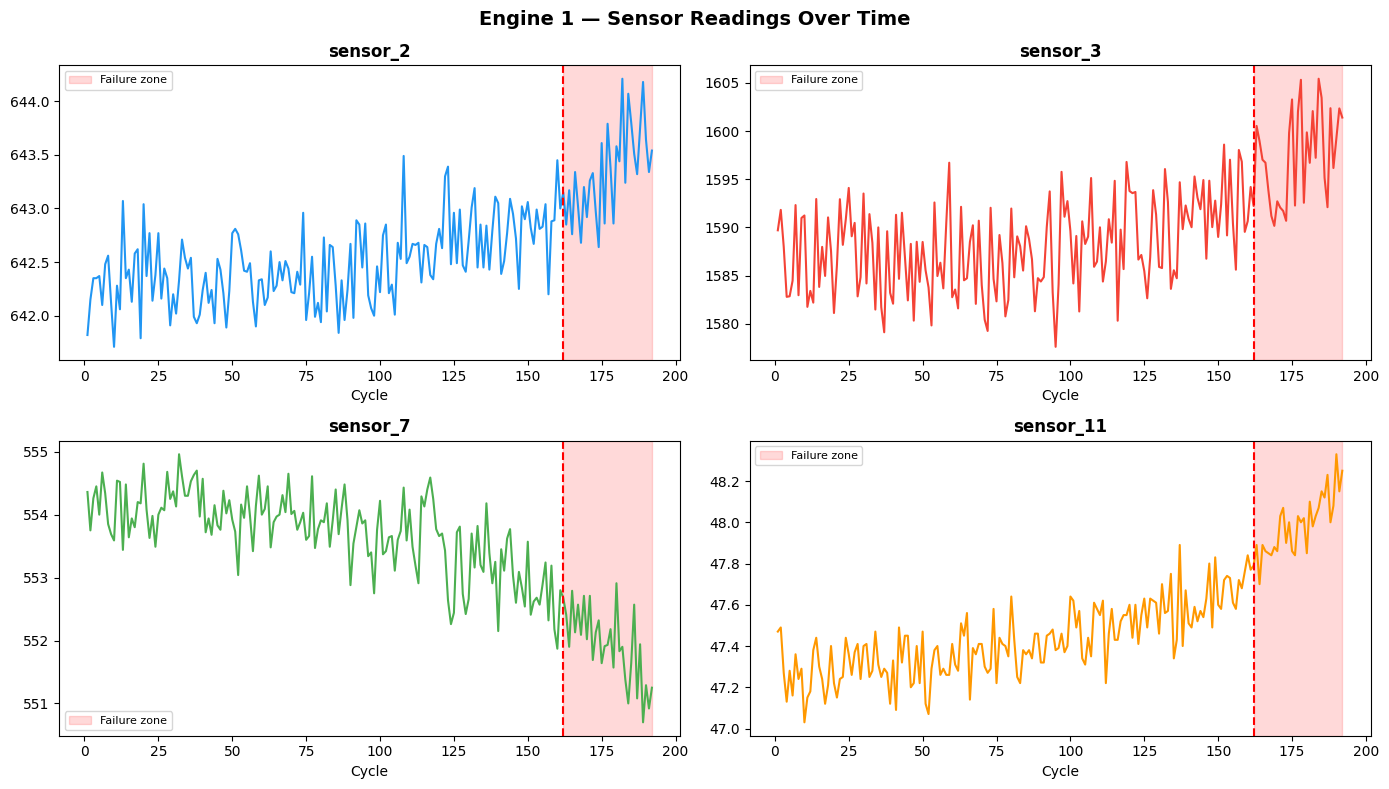

✅ Plot 1 saved: sensor_trends.png


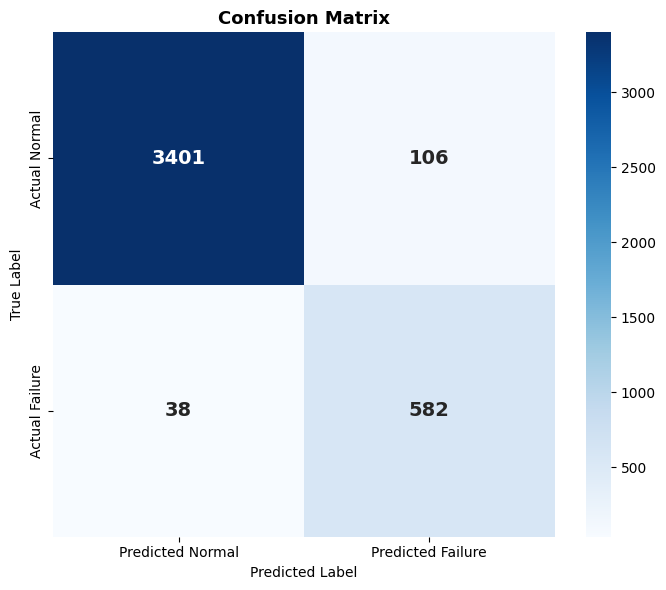

✅ Plot 2 saved: confusion_matrix.png


In [11]:
# ── PLOT 1: Sensor Trend for Engine 1
engine1 = df[df['engine_id']==1].sort_values('cycle')
sensors_to_plot = ['sensor_2','sensor_3','sensor_7','sensor_11']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Engine 1 — Sensor Readings Over Time', fontsize=14, fontweight='bold')
axes = axes.flatten()
colors = ['#2196F3','#F44336','#4CAF50','#FF9800']

for i, (s, c) in enumerate(zip(sensors_to_plot, colors)):
    axes[i].plot(engine1['cycle'], engine1[s], color=c, linewidth=1.5)
    max_c = engine1['cycle'].max()
    axes[i].axvspan(max_c-30, max_c, alpha=0.15, color='red', label='Failure zone')
    axes[i].axvline(max_c-30, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_title(s, fontweight='bold')
    axes[i].set_xlabel('Cycle')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('sensor_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved: sensor_trends.png")

# ── PLOT 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal','Predicted Failure'],
            yticklabels=['Actual Normal','Actual Failure'],
            annot_kws={"size":14,"weight":"bold"}, ax=ax)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved: confusion_matrix.png")

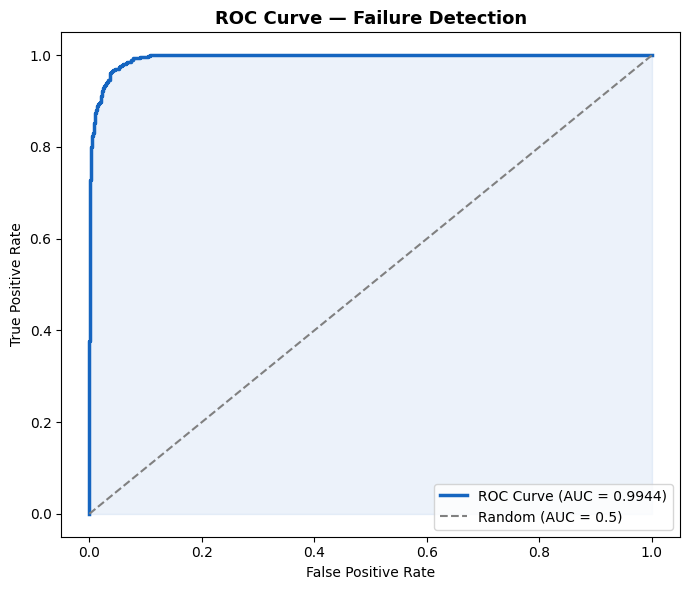

✅ Plot 3 saved: roc_curve.png


In [12]:
# ── PLOT 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#1565C0', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
ax.plot([0,1],[0,1], color='gray', linestyle='--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Failure Detection', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved: roc_curve.png")

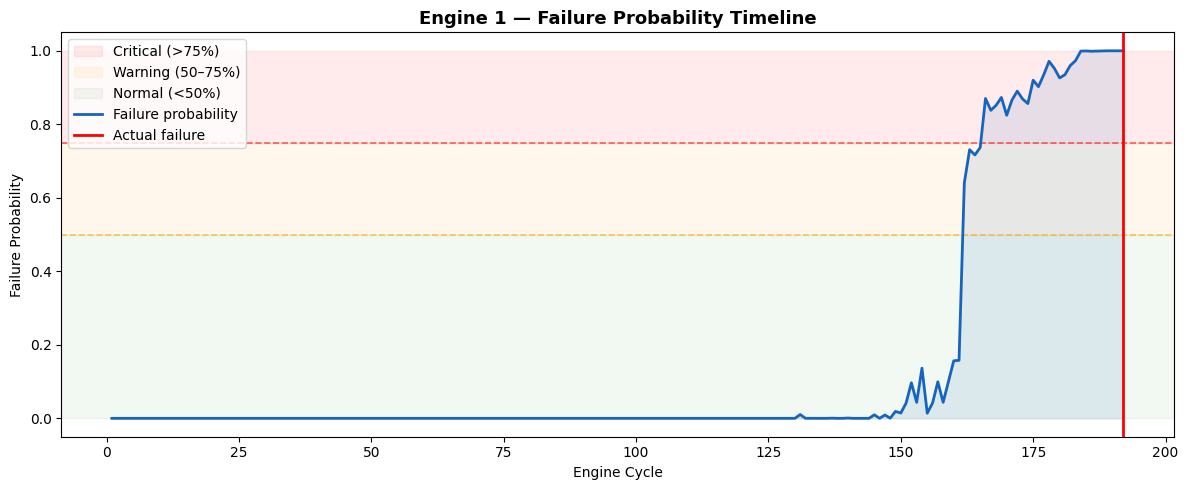

✅ Plot 4 saved: failure_probability.png


In [13]:
# ── PLOT 4: Failure Probability Timeline (Engine 1)
X_e1 = df[df['engine_id']==1][feature_cols]
X_e1_sc = scaler.transform(X_e1)
probs = model.predict_proba(X_e1_sc)[:, 1]
cycles = df[df['engine_id']==1]['cycle'].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhspan(0.75, 1.0, alpha=0.08, color='red',    label='Critical (>75%)')
ax.axhspan(0.50, 0.75, alpha=0.08, color='orange', label='Warning (50–75%)')
ax.axhspan(0.0,  0.50, alpha=0.05, color='green',  label='Normal (<50%)')
ax.axhline(0.75, color='red',    linestyle='--', linewidth=1.2, alpha=0.6)
ax.axhline(0.50, color='orange', linestyle='--', linewidth=1.2, alpha=0.6)
ax.plot(cycles, probs, color='#1565C0', linewidth=2, label='Failure probability')
ax.fill_between(cycles, probs, alpha=0.1, color='#1565C0')
ax.axvline(cycles.max(), color='red', linewidth=2, label='Actual failure')
ax.set_xlabel('Engine Cycle')
ax.set_ylabel('Failure Probability')
ax.set_title('Engine 1 — Failure Probability Timeline', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('failure_probability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved: failure_probability.png")

In [14]:
# Simulate a live sensor reading from the last cycle of Engine 1
# (this engine is at end-of-life, so alert should fire!)
last_reading = df[df['engine_id']==1].tail(1)[feature_cols]
X_live = scaler.transform(last_reading)

prob = model.predict_proba(X_live)[0][1]
pred = model.predict(X_live)[0]

print("="*45)
print("   🔴 LIVE MACHINE HEALTH CHECK")
print("="*45)
print(f"   Failure Probability : {prob*100:.2f}%")
print(f"   Prediction          : {'FAILURE' if pred==1 else 'NORMAL'}")

if prob >= 0.75:
    print("   Alert Level        : ⛔ CRITICAL")
    print("   → Immediate maintenance required!")
elif prob >= 0.50:
    print("   Alert Level        : ⚠️  WARNING")
    print("   → Schedule maintenance soon.")
else:
    print("   Alert Level        : ✅ NORMAL")
    print("   → Machine is healthy.")
print("="*45)

   🔴 LIVE MACHINE HEALTH CHECK
   Failure Probability : 99.98%
   Prediction          : FAILURE
   Alert Level        : ⛔ CRITICAL
   → Immediate maintenance required!


In [15]:
# Save trained model
joblib.dump({'model': model, 'scaler': scaler}, 'rf_model.pkl')
print("✅ Model saved: rf_model.pkl")

# Download all files to your computer
from google.colab import files
files.download('rf_model.pkl')
files.download('sensor_trends.png')
files.download('confusion_matrix.png')
files.download('roc_curve.png')
files.download('failure_probability.png')
print("✅ All files downloaded!")

✅ Model saved: rf_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
